In [1]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense, Conv2D, Flatten , MaxPooling2D
from keras import Sequential
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# LOAD MNIST DATASETS
(X_train, y_train), (X_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# NORMALISE PIXEL VALUES TO 0-1 RANGE
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [4]:
# RESHAPE DATA TO ADD CHANNEL DIMENSION  (GRAYSCALE = 1 CHANNEL)
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)


In [5]:
X_train[1].shape
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [6]:
# ONE HOT ENCODE THE LABELS
y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)


In [7]:
y_test[1]


array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [8]:
model = Sequential()
model.add(Conv2D(32, kernel_size = (3,3), padding='valid', activation='relu', input_shape = (28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2), strides = 2, padding='valid'))

model.add(Conv2D(32, kernel_size = (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides = 2, padding='valid'))



model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-24 03:23:53.684972: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,386 (442.91 KB)

 Trainable params: 113,386 (442.91 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss = 'categorical_crossentropy',
             optimizer='adam',
              metrics=['accuracy']
             )

In [11]:
history = model.fit(X_train, y_train, batch_size = 128, epochs=5, validation_data = (X_test, y_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9285 - loss: 0.2455 - val_accuracy: 0.9792 - val_loss: 0.0674
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9803 - loss: 0.0650 - val_accuracy: 0.9845 - val_loss: 0.0485
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9856 - loss: 0.0466 - val_accuracy: 0.9840 - val_loss: 0.0460
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9888 - loss: 0.0358 - val_accuracy: 0.9867 - val_loss: 0.0386
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.9906 - loss: 0.0300 - val_accuracy: 0.9903 - val_loss: 0.0307


In [12]:
# VISUALIZE SOME PREDICTIONS

In [13]:
predictions = model.predict(X_test[:5])
predicted_classes = np.argmax(predictions,axis = 1)
true_classes = np.argmax(y_test[:5], axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


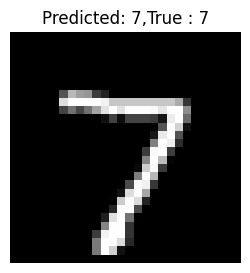

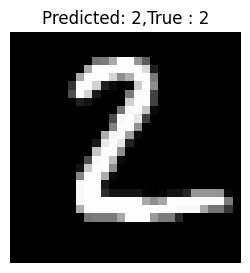

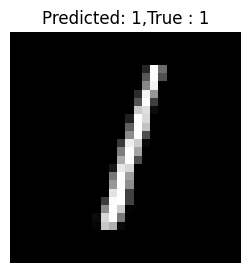

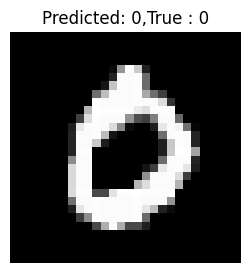

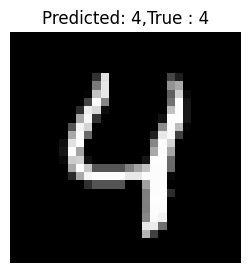

In [14]:
for i in range(5):
    plt.figure(figsize=(3,3))
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f'Predicted: {predicted_classes[i]},True : {true_classes[i]}' )
    plt.axis('off')
    plt.show()